# Supervised Анализ Датасета



In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('cleaned_data.csv')
print(df.shape)



(2455, 20)


### Оценка распределения таргета
По результатам анализа принято решение использовать логарифмированный таргет для обучения модели.


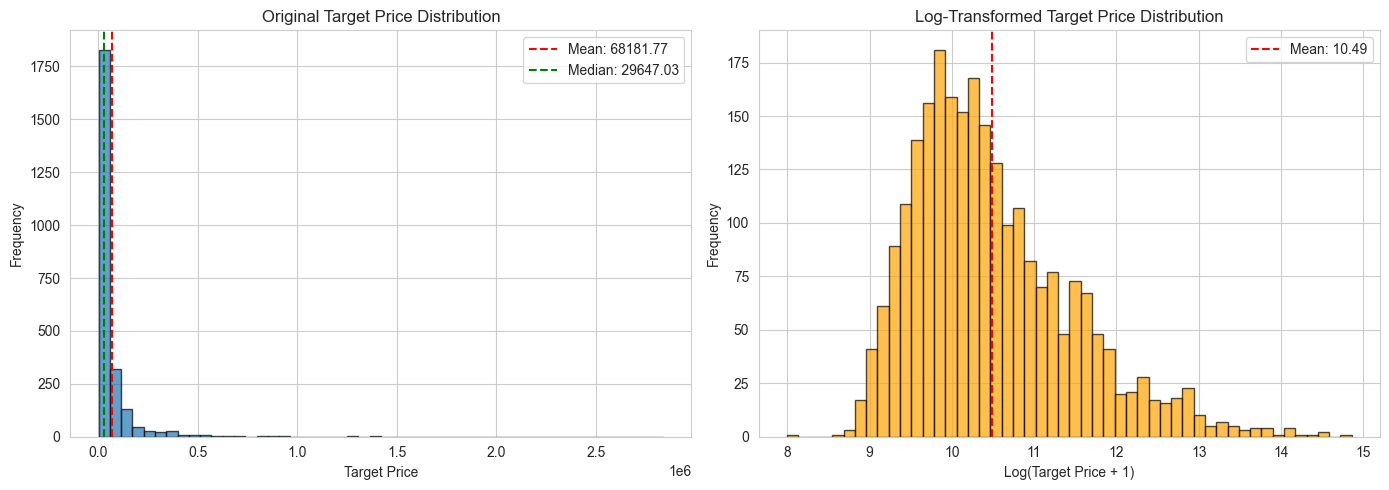


Статистика таргета:
Среднее: 68181.77
Медиана: 29647.03
Среднее квадратичное: 144510.06
Мин: 2977.48
Макс: 2836582.98
Асимметрия: 8.46


In [177]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['log_target'] = np.log1p(df['target_price'])

axes[0].hist(df['target_price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Target Price')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Target Price Distribution')
axes[0].axvline(df['target_price'].mean(), color='red', linestyle='--', label=f'Mean: {df["target_price"].mean():.2f}')
axes[0].axvline(df['target_price'].median(), color='green', linestyle='--', label=f'Median: {df["target_price"].median():.2f}')
axes[0].legend()

axes[1].hist(df['log_target'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Log(Target Price + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Target Price Distribution')
axes[1].axvline(np.log1p(df['target_price']).mean(), color='red', linestyle='--', label=f'Mean: {np.log1p(df["target_price"]).mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nСтатистика таргета:")
print(f"Среднее: {df['target_price'].mean():.2f}")
print(f"Медиана: {df['target_price'].median():.2f}")
print(f"Среднее квадратичное: {df['target_price'].std():.2f}")
print(f"Мин: {df['target_price'].min():.2f}")
print(f"Макс: {df['target_price'].max():.2f}")
print(f"Асимметрия: {df['target_price'].skew():.2f}")

In [178]:
print(f"\nСтатистика log таргета:")
print(f"Среднее: {df['log_target'].mean():.2f}")
print(f"Медиана: {df['log_target'].median():.2f}")
print(f"Среднее квадратичное: {df['log_target'].std():.2f}")
print(f"Мин: {df['log_target'].min():.2f}")
print(f"Макс: {df['log_target'].max():.2f}")
print(f"Асимметрия: {df['log_target'].skew():.2f}")



Статистика log таргета:
Среднее: 10.49
Медиана: 10.30
Среднее квадратичное: 0.97
Мин: 8.00
Макс: 14.86
Асимметрия: 0.97


### Поиск и удаление выбросов

Используется метод квантилей (5 - 95%%)


In [179]:
lower_quantile, upper_quantile = 0.03, 0.85
lower_bound = df['target_price'].quantile(lower_quantile)
upper_bound = df['target_price'].quantile(upper_quantile)

print(f"Границы выбросов: [{lower_bound:.2f}, {upper_bound:.2f}]")

outliers_mask = (df['target_price'] < lower_bound) | (df['target_price'] > upper_bound)
outliers_count = outliers_mask.sum()
print(f"Количество выбросов: {outliers_count} ({outliers_count/len(df)*100:.2f}%)")

df = df[(df['target_price'] >= lower_bound) & (df['target_price'] <= upper_bound)].copy()


Границы выбросов: [9199.08, 100751.03]
Количество выбросов: 441 (17.96%)


In [180]:
df['log_target'] = np.log1p(df['target_price'])

print(f"Log-transformed target statistics:")
print(f"Mean: {df['log_target'].mean():.4f}")
print(f"Std: {df['log_target'].std():.4f}")
print(f"Skewness: {df['log_target'].skew():.4f}")



Log-transformed target statistics:
Mean: 10.2189
Std: 0.5986
Skewness: 0.2883


### 2.4 Feature Distribution Analysis



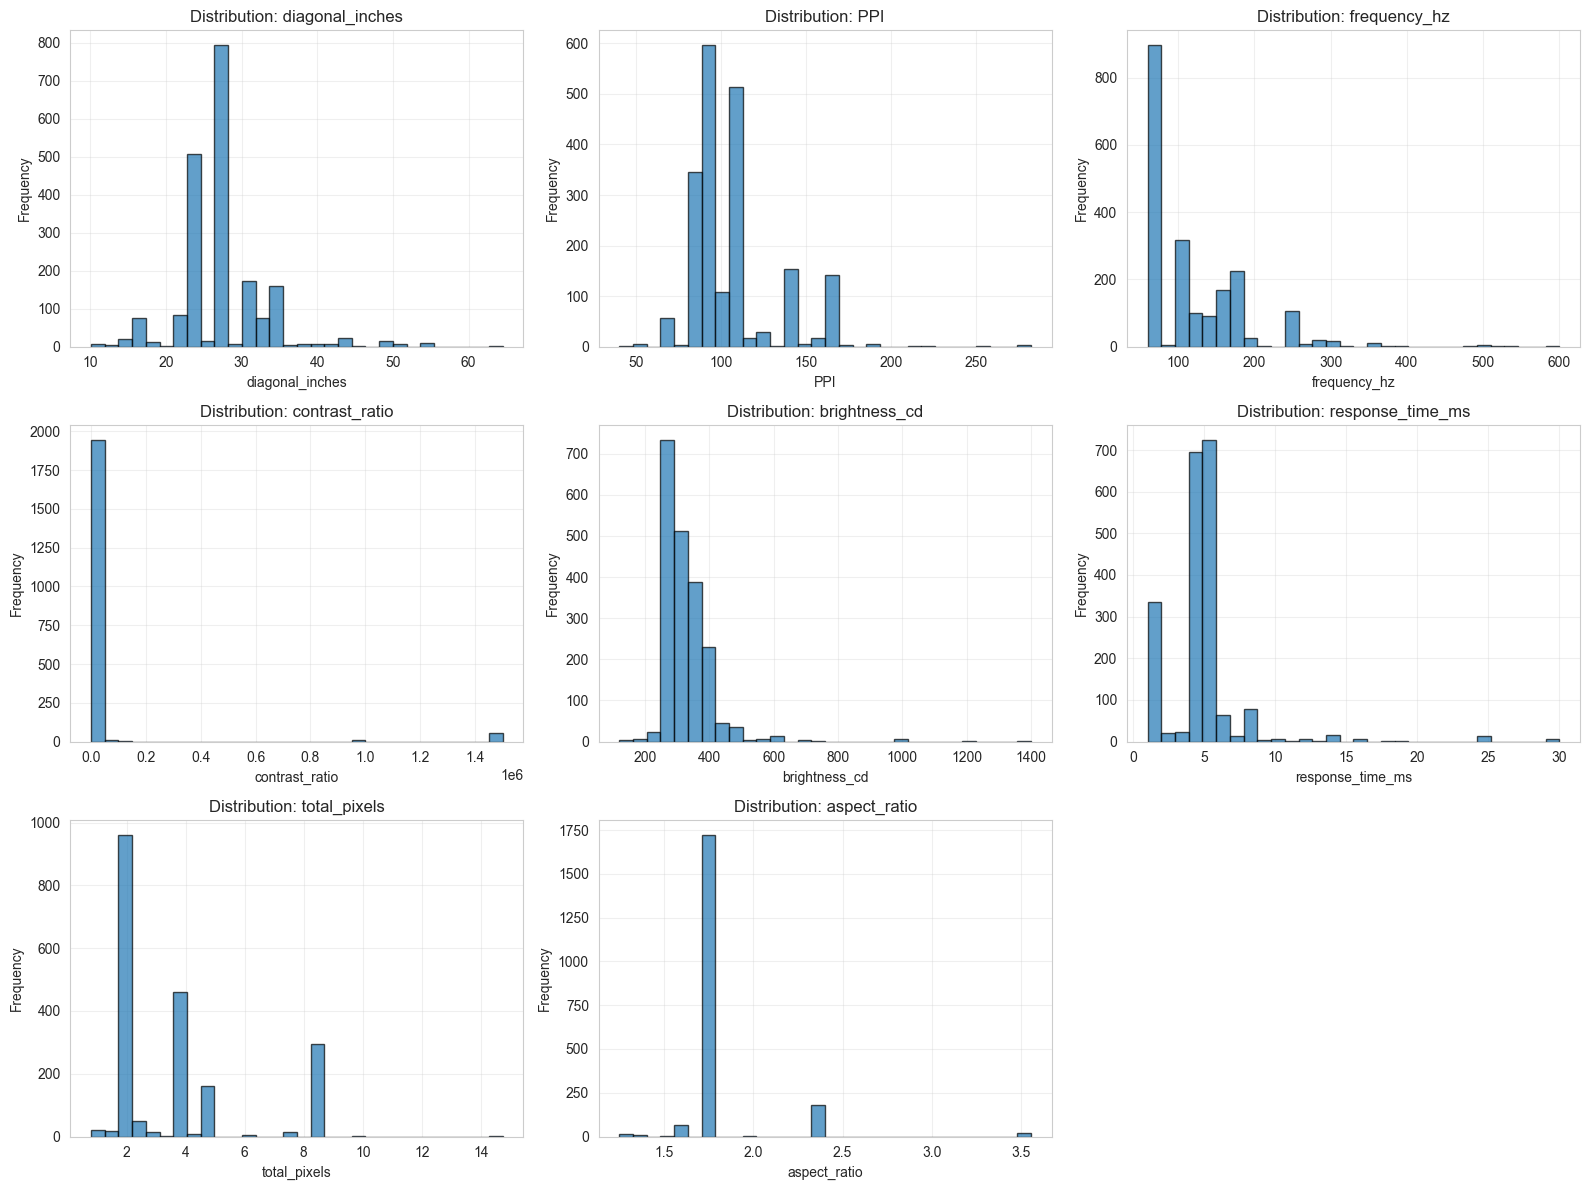

In [181]:
numeric_features = ['diagonal_inches', 'PPI', 'frequency_hz', 'contrast_ratio',
                    'brightness_cd', 'response_time_ms', 'total_pixels', 'aspect_ratio']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    if i < len(axes):
        df[feature].dropna().hist(bins=30, ax=axes[i], edgecolor='black', alpha=0.7)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'Distribution: {feature}')
        axes[i].grid(alpha=0.3)

axes[-1].axis('off')

plt.tight_layout()
plt.show()



### Анализ корреляции



(2012, 9)


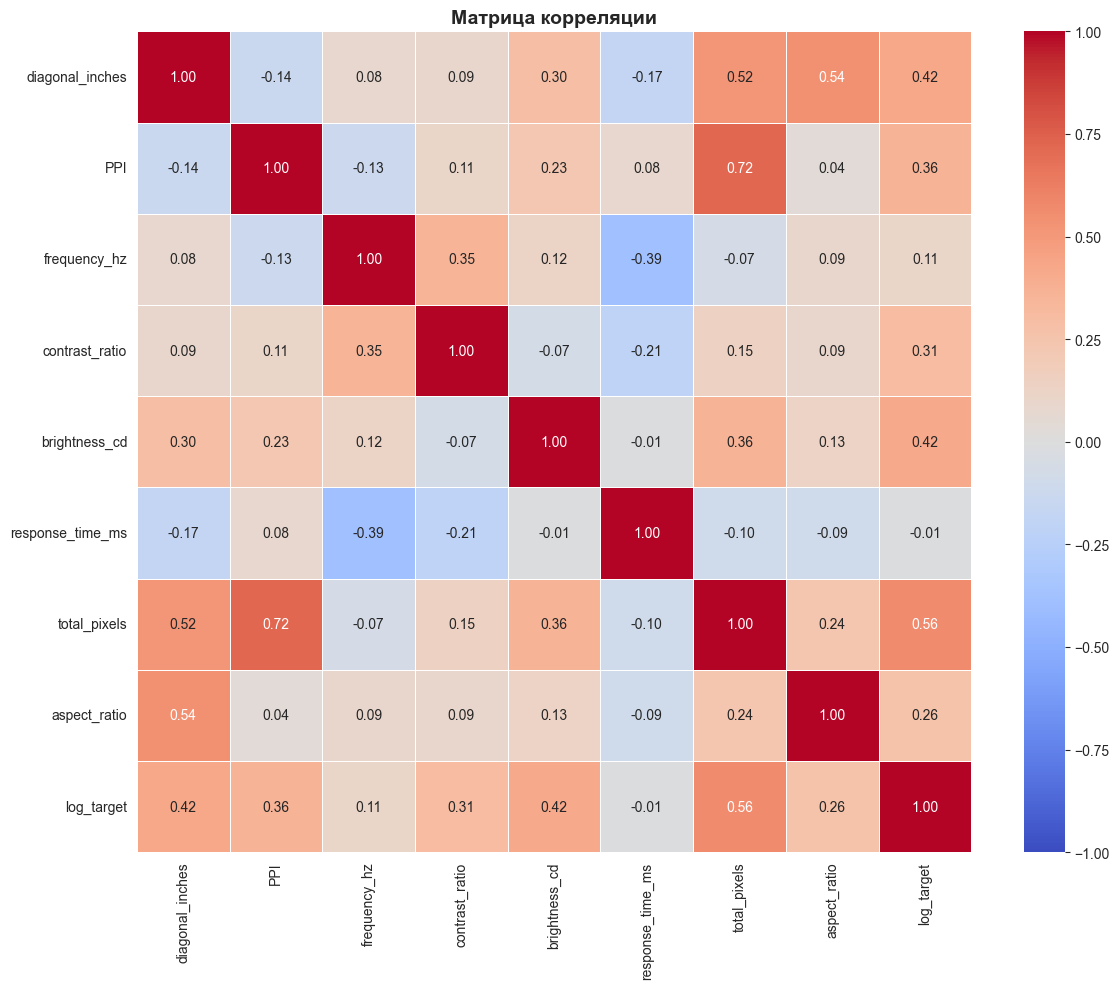


Корреляция с лог таргетом:
log_target          1.000000
total_pixels        0.562829
diagonal_inches     0.423877
brightness_cd       0.420323
PPI                 0.360510
contrast_ratio      0.311884
aspect_ratio        0.261964
frequency_hz        0.108875
response_time_ms   -0.014330
Name: log_target, dtype: float64

Метрики с низкой корреляцией (|corr| < 0.1): ['response_time_ms']


In [182]:
correlation_features = numeric_features + ['log_target']
correlation_df = df[correlation_features].copy()

correlation_df = correlation_df.apply(pd.to_numeric, errors='coerce')
correlation_df = correlation_df.dropna()
print(correlation_df.shape)

correlation_matrix = correlation_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, center=0, vmin=-1, vmax=1)
plt.title('Матрица корреляции', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nКорреляция с лог таргетом:")
log_target_corr = correlation_matrix['log_target'].sort_values(ascending=False)
print(log_target_corr)

low_corr_features = log_target_corr[abs(log_target_corr) < 0.1].index.tolist()

print(f"\nМетрики с низкой корреляцией (|corr| < 0.1): {low_corr_features}")


### Анализ категориальных метрик



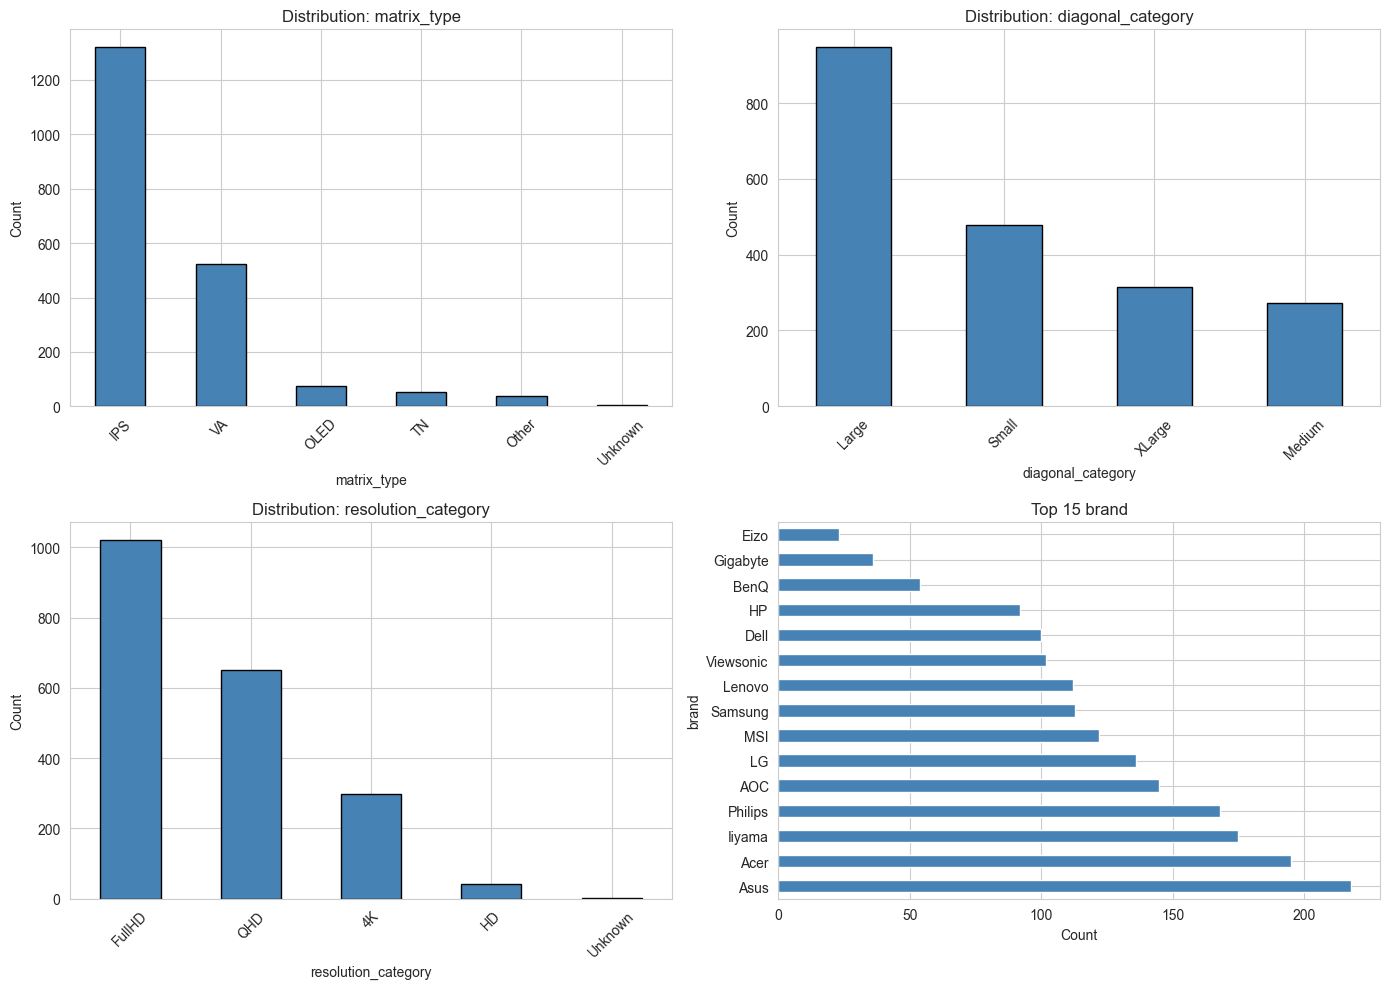

In [183]:
categorical_features = ['matrix_type', 'diagonal_category', 'resolution_category', 'brand']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    if feature == 'brand':

        top_brands = df[feature].value_counts().head(15)
        top_brands.plot(kind='barh', ax=axes[i], color='steelblue')
        axes[i].set_xlabel('Count')
        axes[i].set_title(f'Top 15 {feature}')
    else:
        df[feature].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Count')
        axes[i].set_title(f'Distribution: {feature}')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



### Анализ цен по категориям



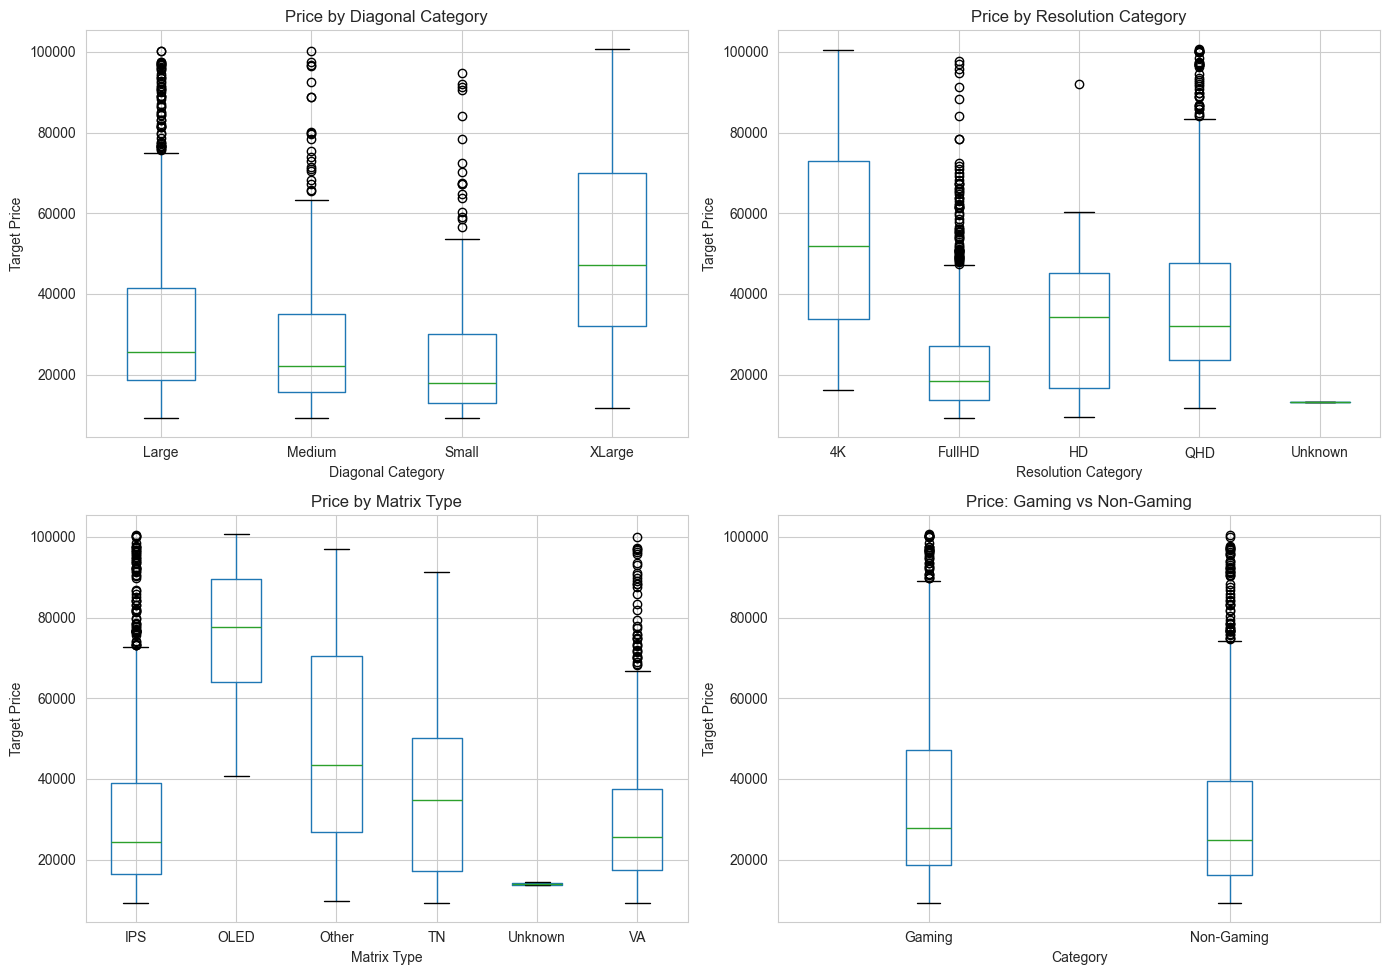

In [184]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.boxplot(column='target_price', by='diagonal_category', ax=axes[0, 0])
axes[0, 0].set_title('Price by Diagonal Category')
axes[0, 0].set_xlabel('Diagonal Category')
axes[0, 0].set_ylabel('Target Price')

df.boxplot(column='target_price', by='resolution_category', ax=axes[0, 1])
axes[0, 1].set_title('Price by Resolution Category')
axes[0, 1].set_xlabel('Resolution Category')
axes[0, 1].set_ylabel('Target Price')

df.boxplot(column='target_price', by='matrix_type', ax=axes[1, 0])
axes[1, 0].set_title('Price by Matrix Type')
axes[1, 0].set_xlabel('Matrix Type')
axes[1, 0].set_ylabel('Target Price')

df['gaming_label'] = df['is_gaming'].map({0: 'Non-Gaming', 1: 'Gaming'})
df.boxplot(column='target_price', by='gaming_label', ax=axes[1, 1])
axes[1, 1].set_title('Price: Gaming vs Non-Gaming')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Target Price')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Сохранение предобработанных данных



In [185]:
df.to_csv('preprocessed_data.csv', index=False)
print(df.head())

                          name  min_price  max_price  target_price  \
1     Asus TUF Gaming VG279Q1R      836.0     1749.0      28719.35   
4    Asus TUF Gaming VG27AQM5A     1370.0     1740.0      34552.10   
5          Dell Pro Plus P2425      688.0     1012.0      18887.00   
6  Iiyama ProLite TW3226AS-B3P     3225.0     3225.0      71659.50   
7         Eizo FlexScan EV2456     1728.0     2299.0      44739.97   

   diagonal_inches  width_px  height_px  aspect_ratio         PPI  \
1             27.0    1920.0     1080.0      1.777778   81.589154   
4             27.0    2560.0     1440.0      1.777778  108.785539   
5             24.1    1920.0     1200.0      1.600000   93.948360   
6             31.5    1920.0     1080.0      1.777778   69.933561   
7             24.0    1920.0     1200.0      1.600000   94.339811   

   frequency_hz  ...  matrix_type  response_time_ms total_pixels  \
1         144.0  ...          IPS               4.0       2.0736   
4         300.0  ...        